In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bordado as bd

from tremelique._utils import homogeneous_model_xarray, model
from tremelique._acoustic import Acoustic
from tremelique._wavelets import RickerWavelet

region = [0, 2000, 0, 1500]
spacing = 5
props = {"velocity":1500, "density":1000}

model = model(region, spacing, properties=props)


In [2]:
sim = Acoustic(model=model, dt=0.001)
sim.add_point_source((0, 200), RickerWavelet(1,60))
sim.run(400)

Output()

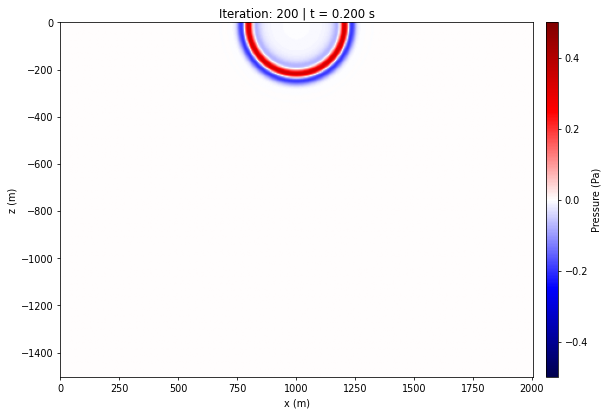

In [3]:
sim.snapshot(200, embed=True, cutoff=0.5)

In [24]:
sim.run(400)

OSError: Unable to synchronously open file (file is already open for read-only)

In [21]:
np.percentile(np.abs(sim.wavefield), 99)

np.float32(0.11944855)

In [22]:
anim = sim.animate_physical(every=10, embed=True, cutoff=0.1)
anim

In [5]:
model.z.attrs["units"] = "m"
model.z.attrs["long_name"] = "vertical"
model.density.attrs["units"] = "kg/m³"

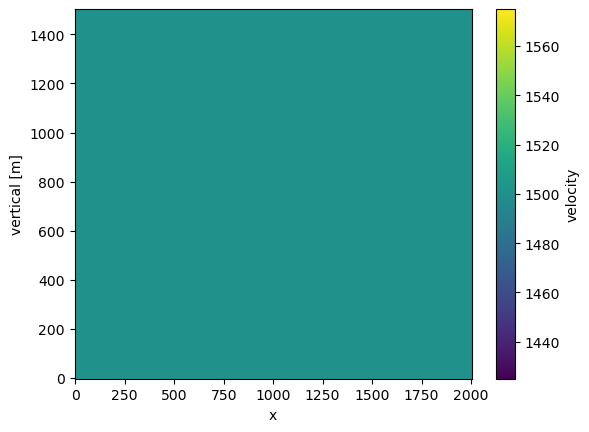

In [6]:
model.velocity.plot()

**Quero**

`sim.wavefield.sel(time=slice(0, 2), x=1000, z=0)`

**Quero está funcionando**

`sim.wavefield.sel(time=slice(0, 2), x=1000, z=0)`

In [7]:
sim.wavefield

<xarray.DataArray 'panels' (time: 400, z: 301, x: 401)> Size: 193MB
[48280400 values with dtype=float32]
Coordinates:
  * time     (time) float64 3kB 0.0 0.001 0.002 0.003 ... 0.397 0.398 0.399
  * z        (z) float32 1kB 0.0 5.0 10.0 15.0 ... 1.49e+03 1.495e+03 1.5e+03
  * x        (x) float32 2kB 0.0 5.0 10.0 15.0 ... 1.99e+03 1.995e+03 2e+03
Attributes:
    units:      Pa
    long_name:  pressure

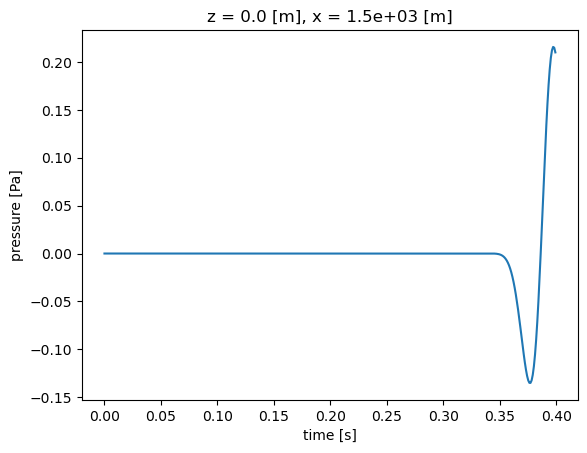

In [8]:
sim.wavefield.sel(time=slice(0, 2), x=1500, z=0).plot()

(np.float64(-2.5), np.float64(2002.5), np.float64(-2.5), np.float64(1502.5))

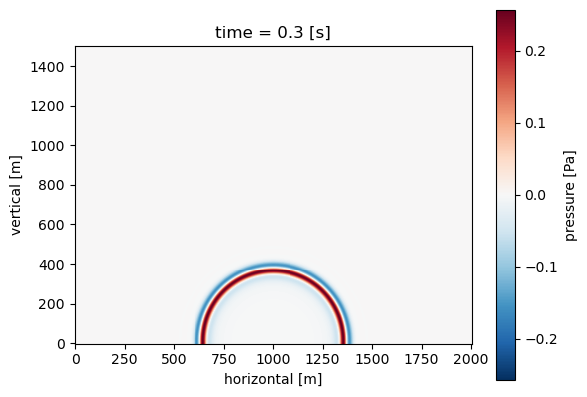

In [13]:
sim.wavefield.sel(time=0.3).plot()
plt.axis("scaled")

In [10]:
plt.imshow(sim[:, 0, :])
plt.show()

KeyError: 'panels'

In [ ]:
model[zname][1] - model[zname][0]